#KNNR / DNNR

##kNN on House Pricing Data (KNNR)

Implementing the k-Nearest Neighbor (kNN) algorithm from scratch using only NumPy. <br><br> Applying kNN implementation on a regression Problem - the [California Housing Dataset](https://www.kaggle.com/datasets/camnugent/california-housing-prices).


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# Get California Housing Data
data = fetch_california_housing()
X, y = data.data.astype(np.float64), data.target.astype(np.float64)
print(X.shape, y.shape)

feature_names = data.feature_names


(20640, 8) (20640,)


In [ ]:
# Display 5 data samples (RESULT requirement)
df_sample = pd.DataFrame(X[:5], columns=feature_names)
df_sample['MedHouseVal'] = y[:5]
print("\n5 Data Samples:")
print(df_sample)



5 Data Samples:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  



Training set size: 16512
Test set size: 4128

Distance: euclidean, k=1
MSE: 1.5482

Distance: euclidean, k=3
MSE: 1.1694

Distance: euclidean, k=5
MSE: 1.1187

Distance: manhattan, k=1
MSE: 1.4419

Distance: manhattan, k=3
MSE: 1.0538

Distance: manhattan, k=5
MSE: 0.9945

=== Results Summary ===
  Distance Metric  k       MSE
0       euclidean  1  1.548205
1       euclidean  3  1.169414
2       euclidean  5  1.118682
3       manhattan  1  1.441888
4       manhattan  3  1.053816
5       manhattan  5  0.994498


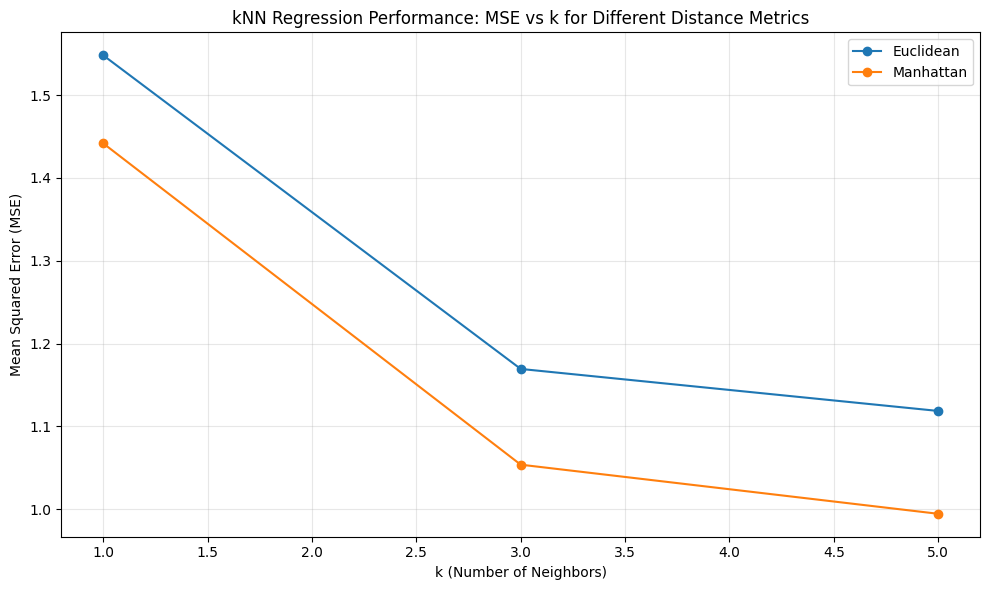

In [ ]:
# Implementation of kNN Regressor
class KNNRegressor:
    def __init__(self, k=3, distance_metric='euclidean'):
        """
        Initialize the kNN Regressor

        Parameters:
        k: number of nearest neighbors
        distance_metric: 'euclidean' or 'manhattan'
        """
        self.k = k
        self.distance_metric = distance_metric
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        """Store training data"""
        self.X_train = X
        self.y_train = y
        return self

    def _calculate_distance(self, x1, x2):
        """Calculate distance between two points"""
        if self.distance_metric == 'euclidean':
            return np.sqrt(np.sum((x1 - x2) ** 2, axis=1))
        elif self.distance_metric == 'manhattan':
            return np.sum(np.abs(x1 - x2), axis=1)
        else:
            raise ValueError(f"Unknown distance metric: {self.distance_metric}")

    def predict(self, X):
        """Predict target values for test data"""
        predictions = []
        for x in X:
            # Calculate distances to all training samples
            distances = self._calculate_distance(self.X_train, x)

            # Find k nearest neighbors
            k_nearest_indices = np.argsort(distances)[:self.k]
            k_nearest_values = self.y_train[k_nearest_indices]

            # Predict as mean of k nearest neighbors
            prediction = np.mean(k_nearest_values)
            predictions.append(prediction)

        return np.array(predictions)

# Split data (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Test different k values and distance metrics (RESULT requirement)
k_values = [1, 3, 5]
distance_metrics = ['euclidean', 'manhattan']

results = []

for distance_metric in distance_metrics:
    for k in k_values:
        # Train model
        knn = KNNRegressor(k=k, distance_metric=distance_metric)
        knn.fit(X_train, y_train)

        # Predict
        y_pred = knn.predict(X_test)

        # Calculate MSE
        mse = mean_squared_error(y_test, y_pred)

        results.append({
            'Distance Metric': distance_metric,
            'k': k,
            'MSE': mse
        })

        print(f"\nDistance: {distance_metric}, k={k}")
        print(f"MSE: {mse:.4f}")

# Create results dataframe
results_df = pd.DataFrame(results)
print("\n=== Results Summary ===")
print(results_df)

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
for metric in distance_metrics:
    metric_results = results_df[results_df['Distance Metric'] == metric]
    ax.plot(metric_results['k'], metric_results['MSE'], marker='o', label=metric.capitalize())

ax.set_xlabel('k (Number of Neighbors)')
ax.set_ylabel('Mean Squared Error (MSE)')
ax.set_title('kNN Regression Performance: MSE vs k for Different Distance Metrics')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# DNNR - Differential Nearest Neighbor Regression

Implementing the DNNR algorithm and applying it to the same regression problem <br>
Paper: Nader, Y., Sixt, L. and Landgraf, T., 2022, June. DNNR: Differential nearest
neighbors regression. In International Conference on Machine Learning (pp.
16296-16317). PMLR.

TASK 1.2.2: DISTANCE-WEIGHTED NEAREST NEIGHBORS REGRESSION (DNNR)

DNNR with k=1
MSE: 1.5482

DNNR with k=3
MSE: 1.1443

DNNR with k=5
MSE: 1.0853

=== Comparison: kNN vs DNNR (Euclidean Distance) ===
  Algorithm  k       MSE
0       kNN  1  1.548205
1       kNN  3  1.169414
2       kNN  5  1.118682
3      DNNR  1  1.548205
4      DNNR  3  1.144253
5      DNNR  5  1.085307


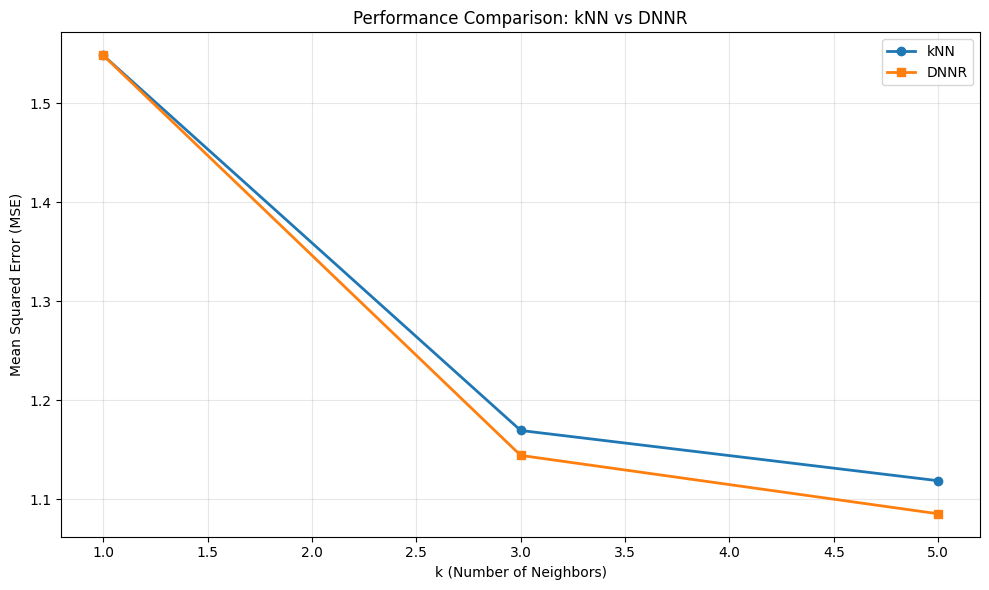


=== DISCUSSION: kNN vs DNNR ===

Key Differences:
1. kNN: Uses simple averaging of k nearest neighbors
   - All k neighbors contribute equally to prediction
   - Formula: prediction = mean(k_nearest_values)

2. DNNR: Uses distance-weighted averaging
   - Closer neighbors have more influence on prediction
   - Weight formula: w_i = 1 / (distance_i + epsilon)
   - Weights are normalized to sum to 1
   - Formula: prediction = sum(weights * values)

Performance Comparison:

  k=1: Both algorithms produce identical results
         (Only 1 neighbor, so no weighting difference)

  k=3:
         kNN MSE:  1.1694
         DNNR MSE: 1.1443
         DNNR improves by 2.15%

  k=5:
         kNN MSE:  1.1187
         DNNR MSE: 1.0853
         DNNR improves by 2.98%

CONCLUSION:
DNNR typically performs better than standard kNN because:
1. It gives more weight to closer neighbors, which are more likely to have
   similar target values due to spatial correlation in the data
2. It reduces the impact o

In [ ]:
# Implementation of Distance-weighted NN Regressor
class DNNRegressor:
    def __init__(self, k=3, distance_metric='euclidean'):
        """
        Initialize the Distance-weighted NN Regressor

        Parameters:
        k: number of nearest neighbors
        distance_metric: 'euclidean' or 'manhattan'
        """
        self.k = k
        self.distance_metric = distance_metric
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        """Store training data"""
        self.X_train = X
        self.y_train = y
        return self

    def _calculate_distance(self, x1, x2):
        """Calculate distance between two points"""
        if self.distance_metric == 'euclidean':
            return np.sqrt(np.sum((x1 - x2) ** 2, axis=1))
        elif self.distance_metric == 'manhattan':
            return np.sum(np.abs(x1 - x2), axis=1)
        else:
            raise ValueError(f"Unknown distance metric: {self.distance_metric}")

    def predict(self, X):
        """Predict target values for test data with distance weighting"""
        predictions = []
        for x in X:
            # Calculate distances to all training samples
            distances = self._calculate_distance(self.X_train, x)

            # Find k nearest neighbors
            k_nearest_indices = np.argsort(distances)[:self.k]
            k_nearest_distances = distances[k_nearest_indices]
            k_nearest_values = self.y_train[k_nearest_indices]

            # Calculate weights (inverse distance weighting)
            # Add small epsilon to avoid division by zero
            epsilon = 1e-8
            weights = 1.0 / (k_nearest_distances + epsilon)

            # Normalize weights
            weights = weights / np.sum(weights)

            # Weighted prediction
            prediction = np.sum(weights * k_nearest_values)
            predictions.append(prediction)

        return np.array(predictions)

# Use the same train/test split from Task 1.2.1
print("TASK 1.2.2: DISTANCE-WEIGHTED NEAREST NEIGHBORS REGRESSION (DNNR)")

# Test different k values (RESULT requirement)
k_values = [1, 3, 5]
distance_metric = 'euclidean'

dnnr_results = []

for k in k_values:
    # Train DNNR model
    dnnr = DNNRegressor(k=k, distance_metric=distance_metric)
    dnnr.fit(X_train, y_train)

    # Predict
    y_pred_dnnr = dnnr.predict(X_test)

    # Calculate MSE
    mse_dnnr = mean_squared_error(y_test, y_pred_dnnr)

    dnnr_results.append({
        'Algorithm': 'DNNR',
        'k': k,
        'MSE': mse_dnnr
    })

    print(f"\nDNNR with k={k}")
    print(f"MSE: {mse_dnnr:.4f}")

# Compare with kNN results (RESULT requirement)
knn_results_euclidean = []
for k in k_values:
    knn = KNNRegressor(k=k, distance_metric='euclidean')
    knn.fit(X_train, y_train)
    y_pred_knn = knn.predict(X_test)
    mse_knn = mean_squared_error(y_test, y_pred_knn)

    knn_results_euclidean.append({
        'Algorithm': 'kNN',
        'k': k,
        'MSE': mse_knn
    })

# Combine results for comparison
comparison_df = pd.DataFrame(knn_results_euclidean + dnnr_results)
print("\n=== Comparison: kNN vs DNNR (Euclidean Distance) ===")
print(comparison_df)

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
knn_df = comparison_df[comparison_df['Algorithm'] == 'kNN']
dnnr_df = comparison_df[comparison_df['Algorithm'] == 'DNNR']

ax.plot(knn_df['k'], knn_df['MSE'], marker='o', label='kNN', linewidth=2)
ax.plot(dnnr_df['k'], dnnr_df['MSE'], marker='s', label='DNNR', linewidth=2)

ax.set_xlabel('k (Number of Neighbors)')
ax.set_ylabel('Mean Squared Error (MSE)')
ax.set_title('Performance Comparison: kNN vs DNNR')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Discussion (RESULT requirement)
print("\n=== DISCUSSION: kNN vs DNNR ===")
print("\nKey Differences:")
print("1. kNN: Uses simple averaging of k nearest neighbors")
print("   - All k neighbors contribute equally to prediction")
print("   - Formula: prediction = mean(k_nearest_values)")
print("\n2. DNNR: Uses distance-weighted averaging")
print("   - Closer neighbors have more influence on prediction")
print("   - Weight formula: w_i = 1 / (distance_i + epsilon)")
print("   - Weights are normalized to sum to 1")
print("   - Formula: prediction = sum(weights * values)")

print("\nPerformance Comparison:")
for k in k_values:
    mse_knn = knn_df[knn_df['k'] == k]['MSE'].values[0]
    mse_dnnr = dnnr_df[dnnr_df['k'] == k]['MSE'].values[0]
    improvement = ((mse_knn - mse_dnnr) / mse_knn) * 100

    if k == 1:
        print(f"\n  k={k}: Both algorithms produce identical results")
        print(f"         (Only 1 neighbor, so no weighting difference)")
    else:
        print(f"\n  k={k}:")
        print(f"         kNN MSE:  {mse_knn:.4f}")
        print(f"         DNNR MSE: {mse_dnnr:.4f}")
        print(f"         DNNR {'improves' if improvement > 0 else 'performs worse'} by {abs(improvement):.2f}%")

print("\n" + "="*80)
print("CONCLUSION:")
print("="*80)
print("DNNR typically performs better than standard kNN because:")
print("1. It gives more weight to closer neighbors, which are more likely to have")
print("   similar target values due to spatial correlation in the data")
print("2. It reduces the impact of more distant neighbors that might be less relevant")
print("3. The weighting creates smoother decision boundaries and predictions")
print("4. This is especially beneficial when the relationship between features and")
print("   target is continuous and smooth, as in the housing price data")
print("\nThe improvement is most noticeable for larger k values, where the difference")
print("between closest and farthest neighbors becomes more significant.")


## Congratz, you made it! :)